# Notebook 2 — Where the sunlight actually falls

### Orbital geometry, the seasons, and why the atmosphere has to move heat

In Notebook 1 the whole planet was a single number. That model could not have an
equator or a pole, a summer or a winter, a wind or a raindrop.

Here we add the single most important ingredient in all of climate dynamics: the
**uneven distribution of sunlight**. Everything else — the Hadley circulation,
the jet stream, the trade winds, the ITCZ we are ultimately chasing — is the
atmosphere's response to the fact that the tropics receive more energy than they
emit and the poles receive less.

You will derive the insolation formula from scratch, reproduce one of the most
reproduced figures in the field, compute how much heat the Earth *must* move
poleward, and then change the tilt of the planet to see the ice ages.

**New Python in this notebook:** 2-D arrays, `np.meshgrid`, `contourf`, and
building your own colour maps.

---

> **Setup.** This notebook needs only `numpy`, `scipy` and `matplotlib` — no
> data files, no downloads. If you have already run
> `00_observed_rainfall.ipynb`, use the same kernel and you are ready. If you
> have not set anything up yet, open that notebook and follow the
> *Before you start* section: Codespaces takes about five minutes and installs
> nothing on your laptop.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
C_YELLOW, C_MAGENTA, C_VIOLET, C_RED = "#eda100", "#e87ba4", "#4a3aa7", "#e34948"
C_INK, C_MUTED, C_GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.figsize": (8, 4.6), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C_INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "text.color": C_INK, "font.size": 10,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

# A one-hue sequential colour map for magnitude, and a two-hue diverging one
# with a neutral midpoint for differences. Never use a rainbow for either.
CMAP_SEQ = LinearSegmentedColormap.from_list("blues", [
    "#eef5fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#256abf", "#184f95", "#0d366b"])
CMAP_DIV = LinearSegmentedColormap.from_list("bl_rd", [
    "#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#f3b0af", "#e34948", "#8f1f1e"])

# numpy renamed trapz -> trapezoid in v2. This works either way.
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

print("Ready.")

Ready.


---
## 1. The Sun's angle in the sky

Everything follows from one quantity: the **solar zenith angle** $Z$, the angle
between the Sun and straight up. A beam of strength $S$ striking a surface at
zenith angle $Z$ delivers only $S\cos Z$ per unit area — the same beam smeared
over a larger footprint. That cosine is why the poles are cold.

Spherical trigonometry gives

$$\boxed{\;\cos Z = \sin\phi\,\sin\delta \;+\; \cos\phi\,\cos\delta\,\cos h\;}$$

with three angles:

| symbol | name | meaning |
|---|---|---|
| $\phi$ | latitude | where you are |
| $\delta$ | **declination** | the latitude where the Sun is directly overhead today |
| $h$ | hour angle | time of day, $h=0$ at local noon, $2\pi$ per day |

Sanity check it: at the equator ($\phi=0$) at equinox ($\delta=0$) at noon
($h=0$), $\cos Z = 1$ — the Sun is straight overhead. Correct.

### The declination

The Earth's spin axis is tilted by the **obliquity** $\varepsilon = 23.44^\circ$
and keeps pointing the same way as the Earth orbits. Project that fixed tilt onto
the orbital position and you get

$$\delta = \arcsin\big(\sin\varepsilon\,\sin\lambda\big)$$

where $\lambda$ is the angle travelled around the orbit since the March equinox.
Its extremes are $\pm\varepsilon$ — the Tropics of Cancer and Capricorn are
*defined* as the latitudes $\pm 23.44^\circ$ where the Sun can just reach the
zenith.

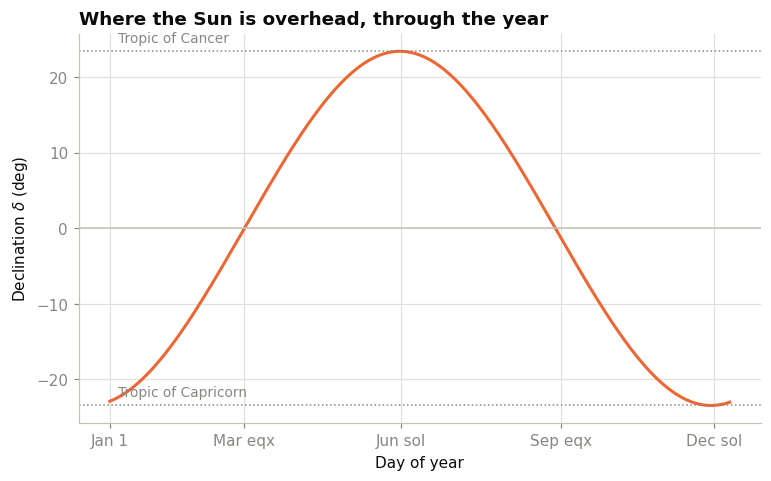

In [2]:
DEG = np.pi / 180.0                 # multiply degrees by this to get radians
S0 = 1361.0                         # solar constant, W m-2
OBLIQUITY = 23.44                   # degrees
DAY_OF_EQUINOX = 80                 # ~21 March


def declination(day, obliquity=OBLIQUITY):
    """Solar declination in radians, for day-of-year 1..365."""
    lam = 2 * np.pi * (day - DAY_OF_EQUINOX) / 365.25      # orbital angle
    return np.arcsin(np.sin(obliquity * DEG) * np.sin(lam))


days = np.arange(1, 366)

fig, ax = plt.subplots()
ax.plot(days, declination(days) / DEG, color=C_ORANGE)
ax.axhline(0, color="#c3c2b7", lw=1)
for y, lab in [(OBLIQUITY, "Tropic of Cancer"), (-OBLIQUITY, "Tropic of Capricorn")]:
    ax.axhline(y, color=C_MUTED, ls=":", lw=1)
    ax.text(6, y + 1.2, lab, color=C_MUTED, fontsize=9)
ax.set_xlabel("Day of year"); ax.set_ylabel(r"Declination $\delta$ (deg)")
ax.set_title("Where the Sun is overhead, through the year")
ax.set_xticks([1, 80, 172, 266, 356])
ax.set_xticklabels(["Jan 1", "Mar eqx", "Jun sol", "Sep eqx", "Dec sol"])
plt.show()

**This curve is the seasons.** The Sun's overhead point sweeps from 23.4°S to
23.4°N and back, once a year. Notice it lingers near the turning points (a sine
wave is flat at its extremes) — which is exactly why "midsummer" is a season and
not an instant. Keep this in mind: the ITCZ, the rainband we are chasing, chases
this curve.

---
## 2. Day length, and the polar night

The Sun is up when $\cos Z > 0$. Setting $\cos Z = 0$ and solving for the hour
angle gives the **sunset hour angle** $h_0$:

$$\cos h_0 = -\tan\phi\,\tan\delta$$

A cosine cannot exceed 1, so this equation sometimes has *no solution* — and that
is not a bug, it is the polar day and polar night:

$$-\tan\phi\tan\delta > 1 \;\Rightarrow\; h_0 = 0 \quad\text{(Sun never rises)}$$
$$-\tan\phi\tan\delta < -1 \;\Rightarrow\; h_0 = \pi \quad\text{(Sun never sets)}$$

`np.clip` handles both cases in one line. Day length is then
$24\,h_0/\pi$ hours.

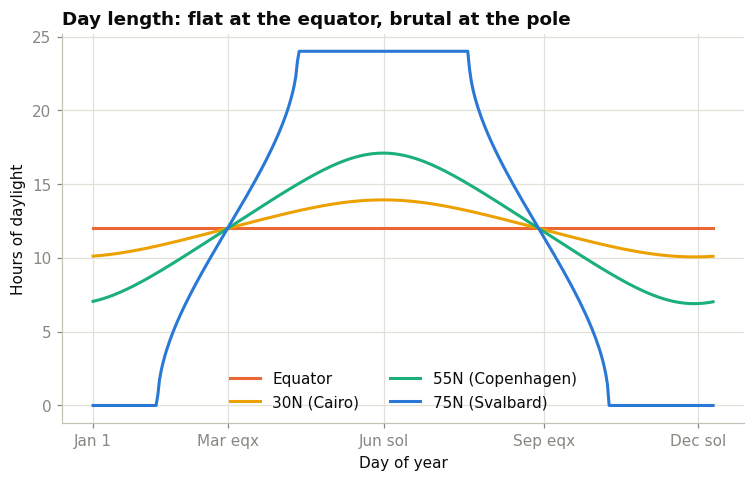

In [3]:
def sunset_hour_angle(lat_deg, day, obliquity=OBLIQUITY):
    """Hour angle of sunset, radians. 0 = polar night, pi = polar day."""
    phi = lat_deg * DEG
    dec = declination(day, obliquity)
    cos_h0 = np.clip(-np.tan(phi) * np.tan(dec), -1.0, 1.0)
    return np.arccos(cos_h0)


fig, ax = plt.subplots()
for lat, col, lab in [(0, C_ORANGE, "Equator"), (30, C_YELLOW, "30N (Cairo)"),
                      (55, C_AQUA, "55N (Copenhagen)"), (75, C_BLUE, "75N (Svalbard)")]:
    ax.plot(days, 24 * sunset_hour_angle(lat, days) / np.pi, color=col, label=lab)
ax.set_xlabel("Day of year"); ax.set_ylabel("Hours of daylight")
ax.set_title("Day length: flat at the equator, brutal at the pole")
ax.set_xticks([1, 80, 172, 266, 356])
ax.set_xticklabels(["Jan 1", "Mar eqx", "Jun sol", "Sep eqx", "Dec sol"])
ax.legend(loc="lower center", ncol=2)
plt.show()

---
## 3. Daily mean insolation — deriving the formula

Now put the two together. The energy arriving per square metre, averaged over a
full 24 hours, is the instantaneous flux integrated from sunrise to sunset and
divided by the whole day:

$$Q = \frac{S_0}{2\pi}\left(\frac{\bar a}{r}\right)^{\!2}
      \int_{-h_0}^{h_0}\!\big(\sin\phi\sin\delta + \cos\phi\cos\delta\cos h\big)\,\mathrm{d}h$$

The $2\pi$ is the full day in hour-angle units. Both terms integrate elementarily
— the first is a constant, the second gives $\sin h$ — and both integrands are
even in $h$, so we get twice the half-range:

$$\boxed{\;Q(\phi,\delta) = \frac{S_0}{\pi}\left(\frac{\bar a}{r}\right)^{\!2}
  \Big[\,h_0\sin\phi\sin\delta \;+\; \cos\phi\cos\delta\sin h_0\,\Big]\;}$$

Two competing effects live in that bracket: the first term is **how long** the
Sun is up, the second is **how high** it gets. At the summer pole the first term
wins outright ($h_0 = \pi$, Sun never sets) even though the Sun is never higher
than 23.4° — which produces a genuinely surprising result in a moment.

The factor $(\bar a/r)^2$ accounts for Earth's slightly elliptical orbit. We keep
it optional: with eccentricity $e$ and $\lambda_p$ the orbital angle of
perihelion,

$$\left(\frac{\bar a}{r}\right)^{2} = \left[\frac{1 + e\cos(\lambda - \lambda_p)}{1-e^2}\right]^{2}.$$

*(We let $\lambda$ advance uniformly in time, which ignores Kepler's second law.
For $e = 0.0167$ the error is small; a research-grade calculation would solve
Kepler's equation. Exercise 5.)*

In [4]:
def daily_insolation(lat_deg, day, obliquity=OBLIQUITY, ecc=0.0, lon_perihelion=282.9):
    """
    Daily mean top-of-atmosphere insolation, W m-2.

    lat_deg, day may be arrays (they broadcast against each other).
    ecc=0 gives a circular orbit; ecc=0.0167 is today's Earth.
    """
    phi = lat_deg * DEG
    dec = declination(day, obliquity)
    h0 = sunset_hour_angle(lat_deg, day, obliquity)

    lam = 2 * np.pi * (day - DAY_OF_EQUINOX) / 365.25
    dist_factor = ((1 + ecc * np.cos(lam - lon_perihelion * DEG)) / (1 - ecc**2)) ** 2

    return (S0 / np.pi) * dist_factor * (
        h0 * np.sin(phi) * np.sin(dec) + np.cos(phi) * np.cos(dec) * np.sin(h0))


# quick check against a number you can verify anywhere
print("Equator, equinox      :", round(float(daily_insolation(0, 80)), 1), "W m-2")
print("North Pole, Jun solst :", round(float(daily_insolation(90, 172)), 1), "W m-2")
print("Equator, Jun solstice :", round(float(daily_insolation(0, 172)), 1), "W m-2")

Equator, equinox      : 433.2 W m-2
North Pole, Jun solst : 541.4 W m-2
Equator, Jun solstice : 397.5 W m-2


**Look at that second number.** On the June solstice the North Pole receives
*more* daily-mean sunlight than the equator does — more than anywhere else on
Earth, on any day. Twenty-four hours of weak sun beats twelve hours of strong
sun. (It is still frozen, because ice reflects most of it away and the ocean
underneath has all winter to cool. Energy *received* is not temperature.)

---
## 4. The figure: insolation as a function of latitude and day

Now we compute $Q$ everywhere, for every day, at once. `np.meshgrid` builds the
2-D grid of coordinate pairs; our function then evaluates on all 181 × 365 points
in a single call, with no loops at all.

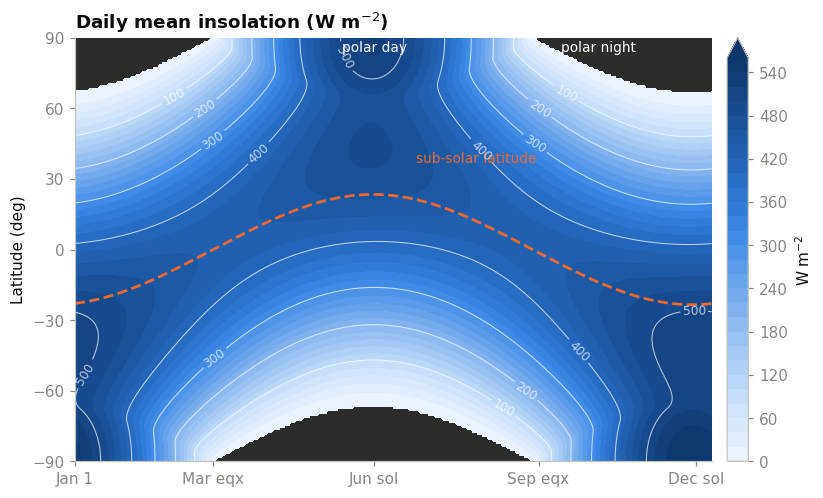

In [5]:
lats = np.linspace(-90, 90, 181)
DAYS, LATS = np.meshgrid(days, lats)          # both are 181 x 365 arrays
Q = daily_insolation(LATS, DAYS, ecc=0.0167)  # today's Earth

fig, ax = plt.subplots(figsize=(9, 5))
levels = np.arange(0, 561, 20)
cf = ax.contourf(DAYS, LATS, Q, levels=levels, cmap=CMAP_SEQ, extend="max")
cs = ax.contour(DAYS, LATS, Q, levels=[100, 200, 300, 400, 500],
                colors="white", linewidths=0.7, alpha=0.7)
ax.clabel(cs, fmt="%d", fontsize=8, colors="white")

# the polar night: the region where the Sun never rises
ax.contourf(DAYS, LATS, Q, levels=[-1, 1e-9], colors=["#2c2c2a"])
ax.text(300, 84, "polar night", color="white", fontsize=9, ha="center")
ax.text(172, 84, "polar day", color="white", fontsize=9, ha="center")

ax.plot(days, declination(days) / DEG, color=C_ORANGE, lw=1.8, ls="--")
ax.text(196, 37, "sub-solar latitude", color=C_ORANGE, fontsize=9)

ax.set_xticks([1, 80, 172, 266, 356])
ax.set_xticklabels(["Jan 1", "Mar eqx", "Jun sol", "Sep eqx", "Dec sol"])
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_ylabel("Latitude (deg)"); ax.set_title("Daily mean insolation (W m$^{-2}$)")
ax.grid(False)
fig.colorbar(cf, ax=ax, label="W m$^{-2}$", pad=0.02)
plt.show()

Things worth staring at:

- The **tropics are flat**. Between about 20°S and 20°N the colour barely changes
  all year. There is no thermal season in the deep tropics — which is why tropical
  climate is organised by *rain*, not temperature.
- The **summer poles are the brightest places on the map**, brighter than the
  equator ever gets.
- The transition at the polar circles is a **cliff**, not a ramp.
- The map is not quite symmetric between the hemispheres. That is the
  eccentricity: the Earth is closest to the Sun in early January, so the southern
  summer is slightly more intense. Set `ecc=0.0` above and re-run to make the
  asymmetry vanish.

---
## 5. The imbalance — and the heat transport it demands

Average $Q$ over the year at each latitude, and compare against what the planet
emits. If the Earth emitted the same OLR everywhere, the tropics would run a
permanent energy *surplus* and the poles a permanent *deficit*.

They are not, in fact, heating and freezing without limit. So something must carry
the surplus poleward. That something is the atmosphere and the ocean, and the
amount they must carry is not a matter of opinion — it follows from this figure.

Steady state means the energy converging into the polar cap south of latitude
$\phi$ exactly balances the net radiation over it:

$$F(\phi) \;=\; 2\pi a^{2}\!\int_{-\pi/2}^{\phi}\Big[\text{ASR}(\phi') - \text{OLR}\Big]\cos\phi'\,\mathrm{d}\phi'$$

where $\cos\phi'\,\mathrm{d}\phi'$ is the area element on a sphere. $F(\phi)$ is
the **total northward energy transport** across that latitude circle, in watts.

Global mean absorbed solar radiation: 238.2 W m-2
Peak northward transport: 5.48 PW at 37 deg N
(observations say about 5.5 PW near 35N -- not bad for 15 lines of code)


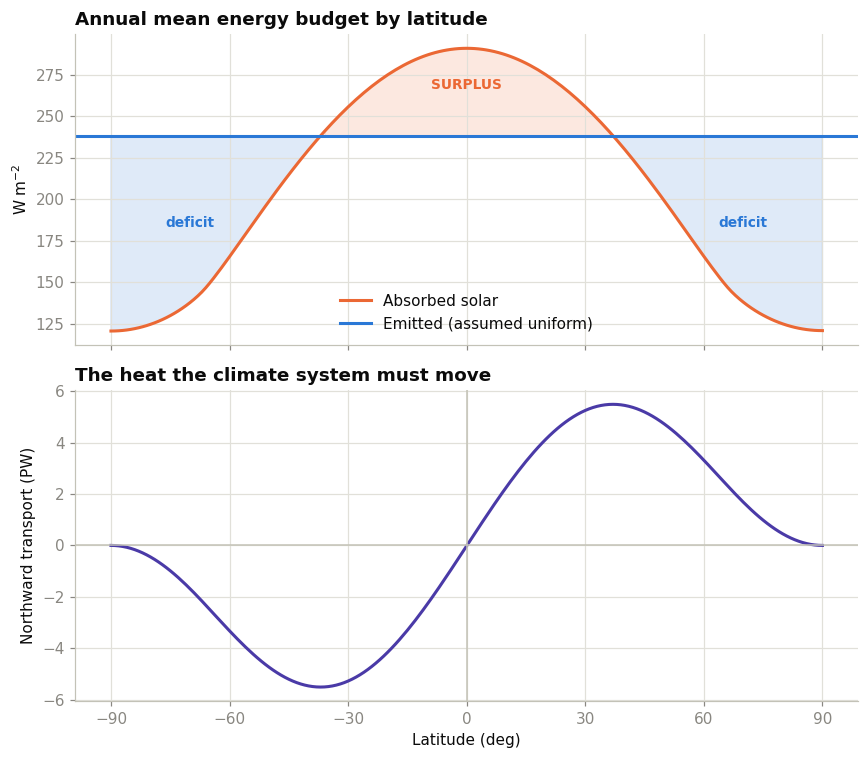

In [6]:
a_earth = 6.371e6                     # Earth radius, m
albedo = 0.30

# NOTE: we deliberately use a CIRCULAR orbit here. Our simplified orbit advances
# lambda uniformly in time, which violates Kepler's second law and leaves a
# spurious hemispheric asymmetry in the annual mean. On the real Earth the planet
# races through perihelion, and the two effects very nearly cancel. Using ecc=0
# keeps the annual mean exactly symmetric, so that any asymmetry appearing later
# is one we put there on purpose rather than a numerical artefact.
Q_circular = daily_insolation(LATS, DAYS, ecc=0.0)

Q_annual = Q_circular.mean(axis=1)    # average over the day axis -> one per latitude
ASR_lat = Q_annual * (1 - albedo)

# global mean, area-weighted: <X> = (1/2) * integral X cos(phi) dphi
w = np.cos(lats * DEG)
ASR_global = trapz(ASR_lat * w, lats * DEG) / trapz(w, lats * DEG)
OLR_uniform = ASR_global              # steady state: what goes out must come in

imbalance = ASR_lat - OLR_uniform
F = 2 * np.pi * a_earth**2 * np.concatenate(
    [[0.0], np.cumsum(0.5 * (imbalance[1:] * w[1:] + imbalance[:-1] * w[:-1])
                      * np.diff(lats * DEG))])

print(f"Global mean absorbed solar radiation: {ASR_global:.1f} W m-2")
print(f"Peak northward transport: {F.max()/1e15:.2f} PW at {lats[F.argmax()]:.0f} deg N")
print("(observations say about 5.5 PW near 35N -- not bad for 15 lines of code)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax1.plot(lats, ASR_lat, color=C_ORANGE, label="Absorbed solar")
ax1.axhline(OLR_uniform, color=C_BLUE, label="Emitted (assumed uniform)")
ax1.fill_between(lats, ASR_lat, OLR_uniform, where=ASR_lat > OLR_uniform,
                 color=C_ORANGE, alpha=0.15)
ax1.fill_between(lats, ASR_lat, OLR_uniform, where=ASR_lat < OLR_uniform,
                 color=C_BLUE, alpha=0.15)
ax1.text(0, OLR_uniform + 28, "SURPLUS", color=C_ORANGE, ha="center", fontsize=9, weight="bold")
ax1.text(-70, OLR_uniform - 55, "deficit", color=C_BLUE, ha="center", fontsize=9, weight="bold")
ax1.text(70, OLR_uniform - 55, "deficit", color=C_BLUE, ha="center", fontsize=9, weight="bold")
ax1.set_ylabel("W m$^{-2}$"); ax1.set_title("Annual mean energy budget by latitude")
ax1.legend(loc="lower center")

ax2.plot(lats, F / 1e15, color=C_VIOLET)
ax2.axhline(0, color="#c3c2b7", lw=1)
ax2.axvline(0, color="#c3c2b7", lw=1)
ax2.set_xlabel("Latitude (deg)"); ax2.set_ylabel("Northward transport (PW)")
ax2.set_title("The heat the climate system must move")
ax2.set_xticks(np.arange(-90, 91, 30))
plt.tight_layout(); plt.show()

### Two things to carry forward

**1. Five petawatts.** That is about 300 times humanity's total energy use, moved
poleward every second by winds and ocean currents. The whole of atmospheric
dynamics — storms, jet streams, the Hadley cell — is machinery for doing this job.

**2. The transport is zero at the equator, in this calculation.** The curve
crosses zero exactly at $\phi = 0$, because a symmetric Sun over a symmetric
planet has no reason to prefer a hemisphere.

**The real Earth does not do this.** Its cross-equatorial energy transport is
about 0.2 PW *southward*, and — as Notebook 3 will show — that small number is
tied to the rainiest band on the planet sitting stubbornly north of the equator.
Understanding why is the door into the double-ITCZ problem.

---
## 6. Changing the tilt: ice ages in four lines

Obliquity is not fixed. It wobbles between roughly 22.1° and 24.5° on a 41,000
year cycle, and those wobbles pace the ice ages. Our formula takes obliquity as
an argument, so we can simply ask what the difference looks like.

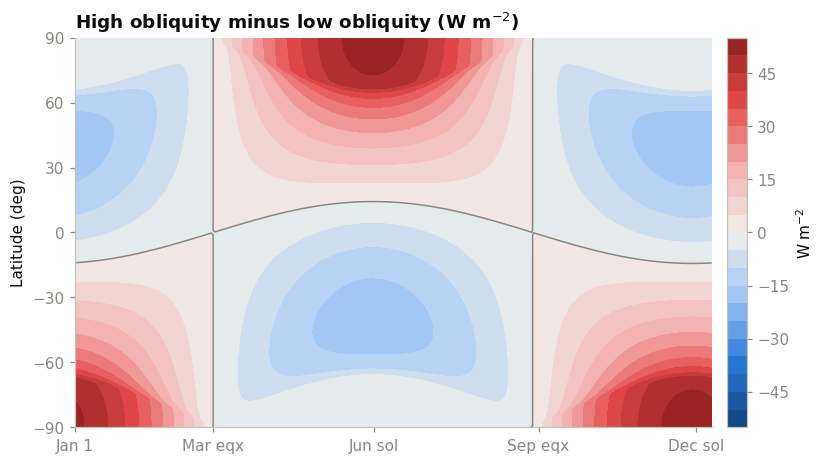

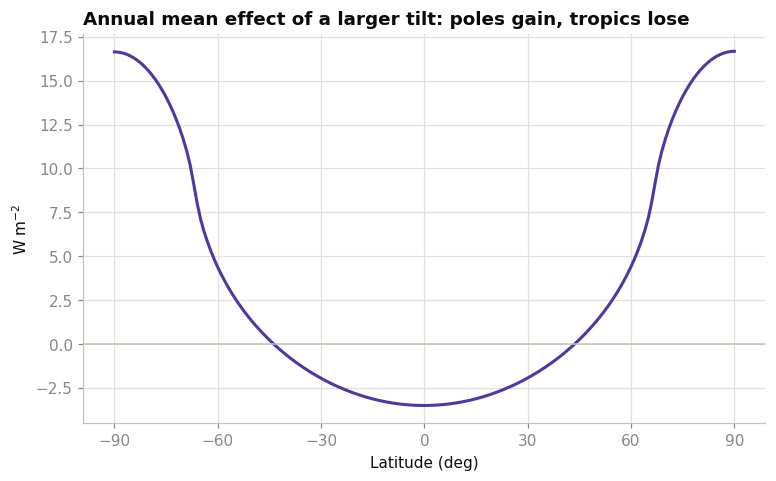

In [7]:
Q_low  = daily_insolation(LATS, DAYS, obliquity=22.1)
Q_high = daily_insolation(LATS, DAYS, obliquity=24.5)
dQ = Q_high - Q_low

fig, ax = plt.subplots(figsize=(9, 4.6))
lim = 5 * np.ceil(np.abs(dQ).max() / 5)          # round up to a tidy number
cf = ax.contourf(DAYS, LATS, dQ, levels=np.arange(-lim, lim + 1, 5), cmap=CMAP_DIV)
ax.contour(DAYS, LATS, dQ, levels=[0], colors=[C_MUTED], linewidths=1)
ax.set_xticks([1, 80, 172, 266, 356])
ax.set_xticklabels(["Jan 1", "Mar eqx", "Jun sol", "Sep eqx", "Dec sol"])
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_ylabel("Latitude (deg)")
ax.set_title("High obliquity minus low obliquity (W m$^{-2}$)")
ax.grid(False)
fig.colorbar(cf, ax=ax, label="W m$^{-2}$", pad=0.02)
plt.show()

fig, ax = plt.subplots()
ax.plot(lats, Q_high.mean(axis=1) - Q_low.mean(axis=1), color=C_VIOLET)
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_xlabel("Latitude (deg)"); ax.set_ylabel("W m$^{-2}$")
ax.set_title("Annual mean effect of a larger tilt: poles gain, tropics lose")
ax.set_xticks(np.arange(-90, 91, 30))
plt.show()

A bigger tilt gives each summer pole more sun and each winter pole less — but the
summer gain wins in the annual mean, because the winter pole is already at zero
and cannot lose more. So **higher obliquity warms the poles and flattens the
equator-to-pole gradient**; lower obliquity sharpens it and lets ice sheets
survive the summer. That is the leading-order Milankovitch story, and you just
derived the energetics of it.

> Note: the *global annual mean* insolation is essentially unchanged — tilt
> redistributes energy, it does not add any. Exercise 3 asks you to verify this.

---
## 7. Where this is going

You now have the forcing. The Sun's energy arrives unevenly, the tropics bank a
surplus, and roughly 5 PW has to be hauled poleward. The atmosphere does that
hauling, and in the deep tropics the machinery is the **Hadley circulation**: air
rises in a narrow band, spreads poleward aloft, sinks in the subtropics, and
returns along the surface as the trade winds.

That narrow rising band is the **Intertropical Convergence Zone (ITCZ)** — the
brightest line of cloud on any satellite image of the Earth, and the source of a
large fraction of the planet's rainfall.

In the real world the Pacific ITCZ sits at about **6°N**, in a single band, for
most of the year. Nearly every coupled climate model ever built puts a *second*
spurious band at about 6°S. The **double-ITCZ bias** is the longest-lived
systematic error in climate modelling: it survived CMIP3, CMIP5 and CMIP6 largely
intact, and it contaminates model projections of tropical rainfall, ENSO, and
monsoons.

So: why should the ITCZ sit north of the equator at all, and what could move it?
Notebook 3 builds a model that answers both.

---
## Exercises

**1. Read the map.** Without running anything: on the insolation map, find the
day and latitude of the single largest value. Explain in two sentences why it is
where it is. Then check with `Q.max()` and `np.unravel_index(Q.argmax(), Q.shape)`.

**2. A planet on its side.** Uranus has an obliquity of 98°. Plot its insolation
map (just call `daily_insolation` with `obliquity=98`). Where is the annual-mean
warmest latitude? Sketch what its "tropics" would mean.

**3. Conservation check.** Compute the global, annual mean insolation for
obliquity 0°, 23.44° and 45°. It should come out at $S_0/4$ every time, to within
rounding. Why must that be true? (Think about what the tilt does and does not
change about the Earth's shadow.)

**4. The Milankovitch index.** Paleoclimatologists care most about **65°N summer
solstice insolation**, because that controls whether northern ice sheets survive
the melt season. Plot it as a function of obliquity from 22° to 24.5°. Then plot
it as a function of `lon_perihelion` from 0° to 360° at fixed obliquity, with
`ecc=0.0167`. Which orbital parameter matters more, and by how much?

**5. Kepler's second law.** Our orbit advances $\lambda$ uniformly in time, but a
real planet moves faster near perihelion. Fix this: solve Kepler's equation
$M = E - e\sin E$ for the eccentric anomaly $E$ (try `scipy.optimize.brentq`),
then get the true anomaly. How much does the insolation map change? Is our
approximation good enough for what we are doing?

**6. Build the bridge.** Compute the **latitude of maximum annual-mean absorbed
solar radiation**, and then the latitude of maximum insolation for each month
separately. Plot the monthly one against month. The real ITCZ migrates over a much
smaller range than this curve does, and lags it by about a month. Write down two
hypotheses for why. (Notebook 3 tests one of them.)